## **TITLE:  LINEAR REGRESSION**

### **Objective**
- To help you understand and remember the complete Machine Learning (ML) pipeline by applying it step-by-step to a Linear Regression problem.

#### **THEORY:**</br>
**Linear Regression**
- Linear Regression is a supervised machine learning algorithm used to predict continuous values (e.g., salary, price).
- It finds the relationship between input feature(s) and output by fitting a best-fit straight line.
- The basic equation is: y = mx + c, where m is slope and c is intercept.
- It is simple, fast, and easy to interpret.


### **🧪 Task 1: Simple Linear Regression (Single Feature)**
Building a simple linear regression model using only one input feature to predict housing prices.

- Input Feature: YearsExperience
- Label: Salary

#### **1. Importing Dependencies**

In [43]:
#Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

#### **2. Data Retrieval and Collection**

In [44]:
df = pd.read_csv("dataset/Salary_Data.csv") #Loading dataset

In [45]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30, 2)


In [46]:
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='str')


In [47]:
print(df.head())

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


#### **3.  Data Cleaning**

In [49]:
df.isnull().sum() 

YearsExperience    0
Salary             0
dtype: int64

In [50]:
df = df.dropna()  #Handling null values by dropping rows with null values

**Explain how missing values were treated (if any).**
- Missing values are handled by dropping the columns having null values.
In this case, we do not have any missing values so handling values wasn't required.

In [51]:
df.dtypes # verifying data types of columns

YearsExperience    float64
Salary               int64
dtype: object

#### **4. Feature Design**

In [52]:
# Separating features (x and y)
X = df[['YearsExperience']]
y = df['Salary']

#### **5. Algorithm Selection**

In [53]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()  

**Explain why linear regression is appropriate for this task.**
- Linear Regression was chosen because it is suitable for predicting continuous values like salary. It works by finding a linear relationship between experience and salary.

#### **6. Loss Function Selection**

In [54]:
from sklearn.metrics import mean_squared_error

**Briefly explain what MSE measures.**
- Mean Squared Error (MSE) was used as the loss function. It measures the average squared difference between actual and predicted values. Lower MSE means better model performance.

#### **7. Model Learning (Training)**

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
) 
#Training the model by splitting the data into training and testing sets, with 20% of the data reserved for testing and a random state of 42 for reproducibility.

In [56]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9478.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.47e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


**Clearly state the learning process.**
- The model was trained using the training dataset. During training, it learned the best-fit line by adjusting the coefficient and intercept to reduce prediction error.

#### **8. Model Evaluation**

In [57]:
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (Slope): 9478.20557998055
Intercept: 24704.095937601305


#### **Model Interpretation**
- Coefficient (Slope): 9478.20
- Intercept: 24704.09

#### **Explanation**

**What does the coefficient represent?**
- For every 1 additional year of experience, the salary increases by approximately 9478 units. This shows a strong positive relationship between experience and salary.

**What does the intercept mean in this context?**
- When the experience is 0 years, the model predicts a starting salary of about 24704 units.

In [58]:
y_pred = model.predict(X_test) # making predictions on the test set using the trained model.

In [59]:
mse = mean_squared_error(y_test, y_pred) 

print("Mean Squared Error:", mse)

Mean Squared Error: 52522472.85879598


In [60]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8824679635169839


**Provide a short interpretation of the results.**

- The MSE interprets how close the predicted values and actual values are.
- The R2 interprets how well the model explains the variation occuring the salaries.

#### **9. Visualization**

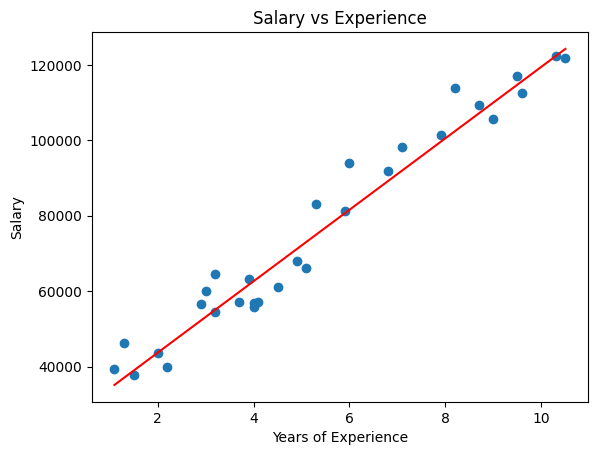

In [61]:
# Visualize the regression line for Task 1
plt.scatter(X, y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")

plt.show()

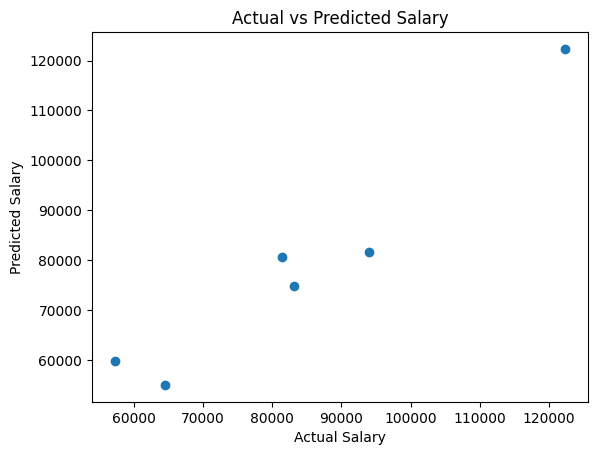

In [62]:
#Plot predicted vs actual values
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

### Discussion

In this lab, we predicted salary based on years of experience using a Linear Regression model. The goal was to understand the full ML pipeline, from data preparation to training and evaluation. 

We observed that the model learns a clear relationship between experience and salary and uses it for prediction. If we use features that actually matter the model will work better. On the hand simpler models are easier to understand, which is a good thing.

Overall this lab really helped us understand how Linear Regression models works and how each step of the process helps us build a model that actually works well. 

### Conclusion

In this lab, we built a simple Linear Regression model step by step. We loaded the data, checked it, trained the model, and evaluated it using MSE and R² score.
It was found that using better features makes the predictions more accurate.

Overall this lab gave us an understanding of Linear Regression and how it works with real-world problems.